# Study of the full crossmatch

In this notebook we study the full crossmatch 

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import copy
# Import own modules
import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src/')

from data_queries import query_extra_data
from plotting_functions import set_styles
from astrometry_equations import rayleigh, compute_error_normalized_distance, predict_G_bv, predict_G_vi

In [28]:
# Define Paths
fpath = '../../../figures/'
rpath = '../../results/'
dpath = '../../../data/'

set_styles()

## Data
We have started by crossmatching all Hipparcos objects at 2, 3, 5 and 10 arcseconds. The resulting lengths are written out in the notebook, but @10" we have found a potential match for 117,812 / 117,955 Hipparcos objects. Each of these objects currently has a best neighbour catalogue selected using nearest and brightest which probably means a lot of objects are false matches. Let's start by checking the 'standard proxies':
- B-V predicted G versus crossmatched G
- Error Normalized Distance

In [29]:
all_2as = np.load(rpath+'final_crossmatch+PMC+EIB_2as_all_neighbours.npy') 
all_3as = np.load(rpath+'final_crossmatch+PMC+EIB_3as_all_neighbours.npy') 
all_5as = np.load(rpath+'final_crossmatch+PMC+EIB_5as_all_neighbours.npy') 
all_10as = np.load(rpath+'final_crossmatch+PMC+EIB_10as_all_neighbours.npy') 

In [31]:
# Hipparcos - Gaia indexes of the cross match 
crossmatch_idxs = all_10as
hipp_cat = fits.open(f'{dpath}Hipparcos_mix.fits')[1].data
gaia_cat = fits.open(f'{dpath}GaiaBaseCat+PMC+EIB.fits')[1].data

# Make a table matching the XM order containing all propagated Gaia astrometry
pos_gaia_table_full = copy.deepcopy(gaia_cat)
pos_gaia_table_full = pos_gaia_table_full[crossmatch_idxs[:,2]]
_, pos_hipp_table_full = query_extra_data(crossmatch_idxs, ['hip', 'ra', 'dec', 'e_ra_rad', 'e_de_rad'], cat='hipp')


# Indexing this table is slightly more work because we do not have the table idxs stored
pos_hipp_table_full = copy.deepcopy(hipp_cat)

hip_indexes = np.zeros(crossmatch_idxs.shape[0], dtype=np.int64)
for i in range(crossmatch_idxs.shape[0]):
    hip_indexes[i] = int(np.where(hipp_cat['hip'] == crossmatch_idxs[i][0])[0][0])
pos_hipp_table_full = pos_hipp_table_full[hip_indexes]

print(f'Imported {crossmatch_idxs.shape[0]} potential Gaia - Hipparcos matches')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
Imported 128072 potential Gaia - Hipparcos matches


### Gaia Predicted versus real Gaia magnitude from crossmatch

For clarity, plot G - G_pred as a function of colour

sigma = 0.02417
100596 object magnitudes well predicted within 1 sigma


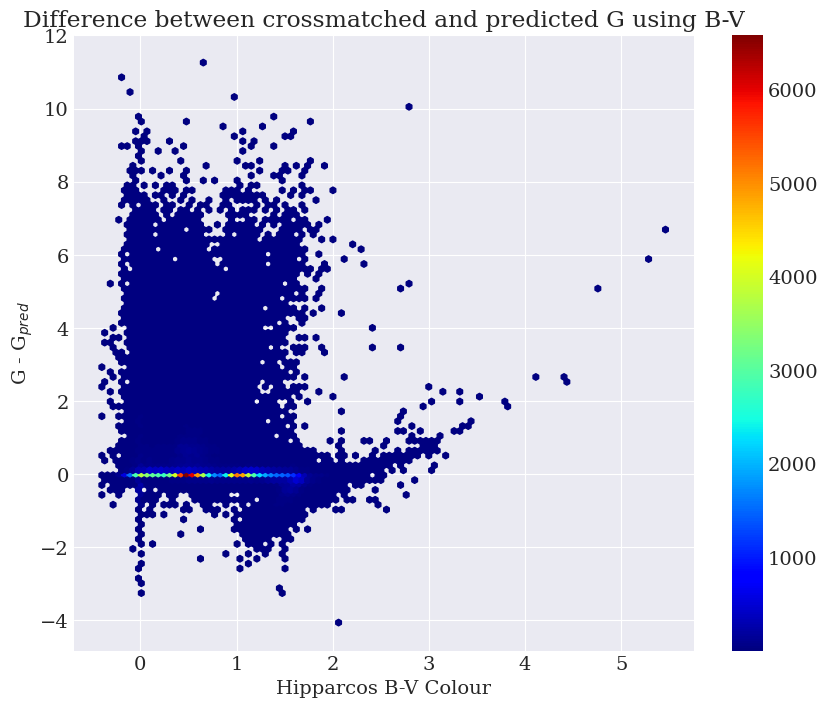

In [64]:
# B-V
G = pos_gaia_table_full['phot_g_mean_mag']
b_v = pos_hipp_table_full['b_v']
hp_mag = pos_hipp_table_full['hp_mag']

G_pred_bv, pred_unc = predict_G_bv(hp_mag, b_v)
print(f'sigma = {pred_unc}')
good_predictions = len(G_pred_bv[np.abs(G-G_pred_bv) < 3*pred_unc])
print(f'{good_predictions} object magnitudes well predicted within 1 sigma')

fig, ax = plt.subplots(1,1,figsize=(10,8))

scatter = ax.hexbin(b_v, G-G_pred_bv, mincnt=1, cmap='jet')
plt.colorbar(scatter)

ax.set_xlabel('Hipparcos B-V Colour')
ax.set_ylabel(r'G - G$_{pred}$')
ax.set_title('Difference between crossmatched and predicted G using B-V')
plt.show()

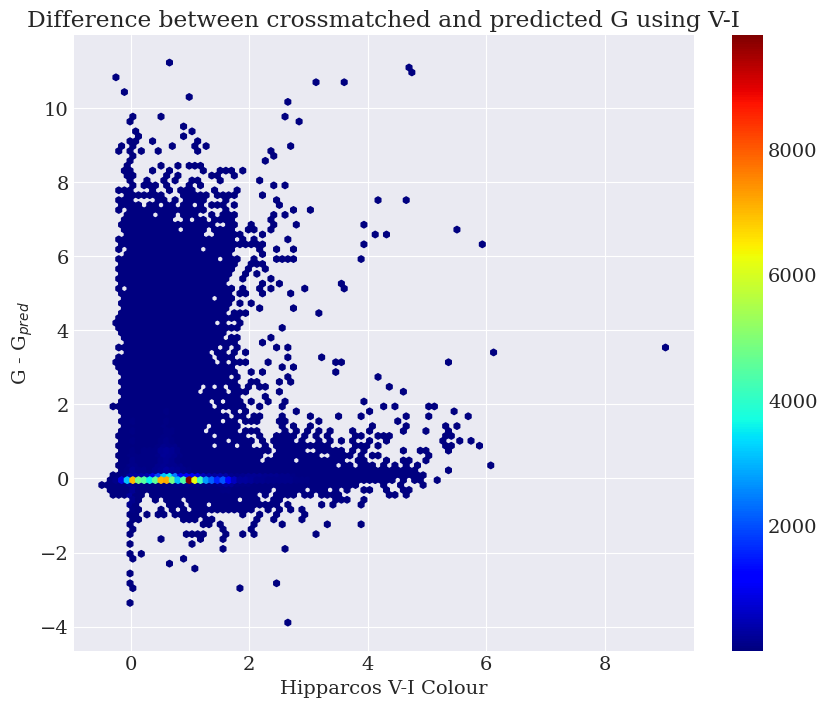

In [65]:
# V-I
# B-V
G = pos_gaia_table_full['phot_g_mean_mag']
v_i = pos_hipp_table_full['v_i']
hp_mag = pos_hipp_table_full['hp_mag']

G_pred_vi, _ = predict_G_vi(hp_mag, v_i)



fig, ax = plt.subplots(1,1,figsize=(10,8))

#scatter = ax.scatter(b_v ,G - G_pred_bv, s=1, c=hp_mag, cmap='jet')
scatter = ax.hexbin(v_i, G-G_pred_vi, mincnt=1, cmap='jet')
plt.colorbar(scatter)
#ax.plot(x, y, c='black', ls='--')

ax.set_xlabel('Hipparcos V-I Colour')
ax.set_ylabel(r'G - G$_{pred}$')
ax.set_title('Difference between crossmatched and predicted G using V-I')

plt.show()